# Sweeps

This notebooks explains *sweeping* in Pulla, that is, performing a loop over a `settings` value. It is recommended to run `Configuration and Usage.ipynb` before this notebook.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
from copy import deepcopy
from pprint import pprint
from IPython.core.display import HTML

from qiskit import QuantumCircuit, visualization
from qiskit.compiler import transpile

from iqm.iqm_client.util import print_env_vars
from iqm.qiskit_iqm import IQMProvider
from iqm.pulla.pulla import Pulla
from iqm.pulla.utils_qiskit import qiskit_to_pulla, sweep_job_to_qiskit, get_qiskit_compiler
from iqm.pulse.playlist.visualisation.base import inspect_playlist
from exa.common.control.sweep.sweep import Sweep
from exa.common.control.sweep.option import CenterSpanOptions
from iqm.pulse.timebox import TimeBox
from iqm.pulse.builder import ScheduleBuilder
from iqm.pulse.playlist.schedule import Segment, Schedule
from iqm.pulse.playlist.instructions import Block

In [ ]:
print_env_vars()

pulla = Pulla()
backend = IQMProvider().get_backend()

## Qiskit Compiler

When running Qiskit circuits through IQM Pulla, one way is to first transpile the circuit manually in your notebook/script, convert the circuit to the IQM representation, and finally compile the circuit for execution.

However, when working on the pulse level, one usually wants to control the routing and transpilation exactly (e.g. route to specific qubits in the chip), whereas the Qiskit transpiler is stochastic in nature. For facilitating pulse-level access in the context of Qiskit, one can use the function `get_qiskit_compiler`. It returns a Pulla compiler which contains the transpilation and conversion to IQM format compiler passes, so that users may just provide native Qiskit `QuantumCircuit`s directly. It also allows easy routing to a subset of a chip.

In [4]:
compiler = get_qiskit_compiler(pulla, backend)

# Show the settings for the transpilation stage pass
compiler.get_settings(circuits=[]).stages.qiskit_transpilation.parallelize_and_transpile

", collection_type=, element_indices=None), value=True, read_only=False, path='stages.qiskit_transpilation.parallelize_and_transpile.perform_move_routing')"">perform_move_routing",True,,perform_move_routing
", collection_type=, element_indices=None), value=True, read_only=False, path='stages.qiskit_transpilation.parallelize_and_transpile.optimize_single_qubits')"">optimize_single_qubits",True,,optimize_single_qubits
", collection_type=, element_indices=None), value=False, read_only=False, path='stages.qiskit_transpilation.parallelize_and_transpile.ignore_barriers_in_1qb_optimization')"">ignore_barriers_in_1qb_optimization",False,,ignore_barriers_in_1qb_optimization
", collection_type=, element_indices=None), value=True, read_only=False, path='stages.qiskit_transpilation.parallelize_and_transpile.remove_final_rzs')"">remove_final_rzs",True,,remove_final_rzs
", collection_type=, element_indices=None), value=None, read_only=False, path='stages.qiskit_transpilation.parallelize_and_transpile.existing_moves_handling')"">existing_moves_handling",not set/auto,,existing_moves_handling
", collection_type=, element_indices=None), value=0, read_only=False, path='stages.qiskit_transpilation.parallelize_and_transpile.optimization_level')"">optimization_level",0,,optimization_level
", collection_type=, element_indices=None), value=None, read_only=False, path='stages.qiskit_transpilation.parallelize_and_transpile.seed_transpiler')"">seed_transpiler",not set/auto,,seed_transpiler
", collection_type=, element_indices=None), value=None, read_only=False, path='stages.qiskit_transpilation.parallelize_and_transpile.num_processes')"">num_processes",not set/auto,,num_processes


In [5]:
# Display the docstring for the stage pass
compiler.show_stages(pass_name="parallelize_and_transpile")

In [6]:
# Compile a Qiskit circuit while fixing some of the transpilation features
qc = QuantumCircuit(2, 2)
qc.x(0)
qc.x(0)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

settings = compiler.get_settings(circuits=[qc])
settings.stages.qiskit_transpilation.parallelize_and_transpile.seed_transpiler = 1  # fix the seed for more deterministic behaviour
settings.stages.qiskit_transpilation.parallelize_and_transpile.optimize_single_qubits = False  # do not remove the two redundant x(0)s

job_definition, context = compiler.compile(
    circuits=[qc],
    components=["QB3", "QB5"],  # this routes the circuit to qubits QB3 and QB5
    settings=settings
)

# Visualize
HTML(inspect_playlist(job_definition.sweep_definition.playlist, [0]))

/home/ville/iqm/repot/continuous-delivery/.dev/environment/venv/lib/python3.11/site-packages/IPython/core/display.py:431: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


It should be noted that the transpilation options exposed in `settings.stages.qiskit_transpilation.parallelize_and_transpile` are not exhaustive. For highly customized transpilation one should still transpile manually and avoid the Qiskit compiler.  

## Sweeps

The specified circuit will be executed with the specified values, resulting in a data point for each different value of the swept quantity. Every setting in the settings tree is in principle sweepable (sweeping some of them makes little sense in practice, but is still _doable_).

### Example: Investigate spectator errors

For optimal QPU performance, each physical component should be "parked" to a flux voltage value that minimizes parasitic interactions with the neighbouring components. The parking is part of the standard calibration of an IQM QPU, but we can investigate its effects by running a two-qubit gate on a connected pair while sweeping a neighbouring coupler's flux voltage. We should see the gate performance getting worse as we get further away from the correct parking voltage.

Create four circuits to prepare the four states `|00>`, `|01>` `|10>` and `|11>` and then perform a CNOT gate between the two qubits. CNOT should map `|10>` to `|11>` and `|11>` to `|10>`, while leaving the other two states intact. We can measure the probability of being in the correct state in all of these cases, which gives us a rough estimate of how much the bad parking affected the gate operation (it should be noted that this is not a scientifically sound method of state/process tomography, but just a simple example for educational purposes).

In [7]:
compiler = get_qiskit_compiler(pulla, backend)

# Prepare |00>
qc1 = QuantumCircuit(2, 2) 
qc1.cx(0,1)
qc1.measure([0,1], [0,1])
    
# Prepare |10>
qc2 = QuantumCircuit(2, 2) 
qc2.x(0)
qc2.cx(0,1)
qc2.measure([0,1], [0,1])
    
# Prepare |01>
qc3 = QuantumCircuit(2, 2) 
qc3.x(1)
qc3.cx(0,1)
qc3.measure([0,1], [0,1])
    
# Prepare |11>
qc4 = QuantumCircuit(2, 2)
qc4.x(0)
qc4.x(1)
qc4.cx(0,1)
qc4.measure([0,1], [0,1])

circuits=[qc1, qc2, qc3, qc4]

# First compile without sweeps
settings = compiler.get_settings(circuits=circuits)
job_definition, context = compiler.compile(
    circuits=circuits,
    components=["QB3", "QB5"],  # run on the pair 3-5
    settings=settings
)

# Run the circuits
job = pulla.submit_playlist(job_definition, context=context)
job.wait_for_completion()

# Instead of the default `job.result()` run the post-processing stages in `compiler` to get the return data in an Xarray Dataset
result = job.result(compiler)
result.dataset

[06-08 17:00:40;I] Waiting for job 019ea789-16f8-78d3-acfd-4da3602d4435 to finish...


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

<xarray.Dataset> Size: 72kB
Dimensions:                                 (circuit_index: 4,
                                             repetitions: 1000, counter_index: 4)
Coordinates:
  * circuit_index                           (circuit_index) int64 32B 0 1 2 3
  * repetitions                             (repetitions) int64 8kB 0 1 ... 999
  * counter_index                           (counter_index) int64 32B 0 1 2 3
Data variables:
    QB3__c_2_0_0_state_single_shot          (circuit_index, repetitions) float64 32kB ...
    QB5__c_2_0_1_state_single_shot          (circuit_index, repetitions) float64 32kB ...
    QB3__c_2_0_0_readout                    (circuit_index) float64 32B 0.052...
    QB5__c_2_0_1_readout                    (circuit_index) float64 32B 0.124...
    QB3__c_2_0_0_excited_state_probability  (circuit_index) float64 32B 0.009...
    QB5__c_2_0_1_excited_state_probability  (circuit_index) float64 32B 0.070...
    counter.result                          (counter_index, circuit_index) float64 128B ...

In [8]:
# In the result dataset, find the bit string probabilities from the data variable "counter.result", and pick the result
# corresponding to each of the four created circuits. Compare the obtained result to the expected theoretical result.
result_for_00 = result.dataset["counter.result"].isel({"circuit_index": 0}).data
print(f"|00> should be mapped to [1.0, 0.0, 0.0, 0.0], we got {result_for_00}, the error is {1-result_for_00[0]}")
result_for_10 = result.dataset["counter.result"].isel({"circuit_index": 1}).data
print(f"|10> should be mapped to [0.0, 0.0, 0.0, 1.0], we got {result_for_10}, the error is {1-result_for_10[3]}")
result_for_01 = result.dataset["counter.result"].isel({"circuit_index": 2}).data
print(f"|01> should be mapped to [0.0, 1.0, 0.0, 0.0], we got {result_for_01}, the error is {1-result_for_01[1]}")
result_for_11 = result.dataset["counter.result"].isel({"circuit_index": 3}).data
print(f"|11> should be mapped to [0.0, 0.0, 1.0, 0.0], we got {result_for_11}, the error is {1-result_for_11[2]}")

|00> should be mapped to [1.0, 0.0, 0.0, 0.0], we got [0.859 0.089 0.017 0.035], the error is 0.14100000000000001
|10> should be mapped to [0.0, 0.0, 0.0, 1.0], we got [0.043 0.047 0.08  0.83 ], the error is 0.17000000000000004
|01> should be mapped to [0.0, 1.0, 0.0, 0.0], we got [0.092 0.853 0.038 0.017], the error is 0.14700000000000002
|11> should be mapped to [0.0, 0.0, 1.0, 0.0], we got [0.049 0.041 0.811 0.099], the error is 0.18899999999999995


In [9]:
# Define the sweep over the couper flux voltage (centered at the correct value, span 0.5V, 30 points)
settings = compiler.get_settings(circuits=circuits)
voltage = settings.controllers["TC-2-3"].flux.voltage
voltage_sweep = voltage.sweep(np.linspace(-0.5, 0.5, 30) + voltage.value)

# Compile and execute
job_definition, context = compiler.compile(
    circuits=circuits,
    components=["QB3", "QB5"],  # run on the pair 3-5
    settings=settings,
    sweeps=[voltage_sweep]
)

# Run the circuits
job = pulla.submit_playlist(job_definition, context=context)
job.wait_for_completion()
result = job.result(compiler)

[06-08 17:00:54;I] Waiting for job 019ea789-4cce-7df0-816b-fc8e0aeb76ec to finish...


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Bias voltage:   0%|          | 0/30 [00:00<?, ?it/s]

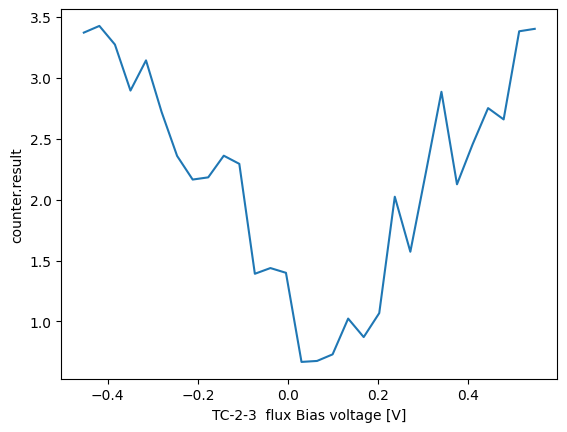

In [10]:
# Plot the resulting errors as a function of the flux voltage with native Xarray plotting (Matplotlib) 
error_for_00 = 1.0 - result.dataset["counter.result"].isel({"circuit_index": 0, "counter_index": 0})
error_for_10 = 1.0 - result.dataset["counter.result"].isel({"circuit_index": 1, "counter_index": 3})
error_for_01 = 1.0 - result.dataset["counter.result"].isel({"circuit_index": 2, "counter_index": 1})
error_for_11 = 1.0 - result.dataset["counter.result"].isel({"circuit_index": 3, "counter_index": 2})
cumulative_error = error_for_00 + error_for_10 + error_for_01 + error_for_11
cumulative_error.plot()

### Example: Parametric circuits and multi-dimensional sweeps

You might have wondered why `compiler.get_settings(circuits)` requires the circuits as an argument. The reason is that the circuit can be a function that creates the actual circuits. The arguments of the circuit generation function then become settings and are thus sweepable, like any other settings.

Compilation also works with multiple sweeps and sweep settings in parallel.

In [11]:
def _my_circuit(n_cz: int = 0) -> list[QuantumCircuit]:
    """Perform ``n_cz`` CZ gates on a pair of qubits."""
    qc = QuantumCircuit(2, 2)
    qc.h(0)
    qc.h(1)
    for _ in range(n_cz):
        qc.cz(0, 1)
    qc.measure_all()
    return [qc]

settings = compiler.get_settings(circuits=_my_circuit)

# n_cz is now a setting in circuit
settings.stages.circuit_generation.circuit

", collection_type=, element_indices=None), value=0, read_only=False, path='stages.circuit_generation.circuit.n_cz')"">n_cz",0,,n_cz


In [12]:
# Sweep over n_cz
n_cz_sweep = Sweep(parameter=settings.stages.circuit_generation.circuit.n_cz.parameter, data=np.array([1,2,3]))

# Sweep over the default PRX amplitude in parallel for the two qubits such that in a single sweep we sweep both amplitudes
amp_sweep = tuple(
    Sweep(parameter=settings.get_gate_node_for_locus("prx", q).amplitude_i.parameter, data=np.array([0.1, 0.2])) for q in ["QB3", "QB5"]
)

# Compile with both sweeps. With multiple sweeps like this the "Cartesian product" of the sweep dimensions is executed,
# such that:
# 1st sweep spot: (n_cz=1, amps=0.1)
# 2nd sweep spot: (n_cz=2, amps=0.1)
# ...
# 4th sweep spot: (n_cz=1, amps=0.2)
# ...
# 6th sweep spot: (n_cz=3, amps=0.2)

job_definition, context = compiler.compile(
    circuits=_my_circuit,
    components=["QB3", "QB5"],
    sweeps=[amp_sweep, n_cz_sweep]
)
HTML(inspect_playlist(job_definition.sweep_definition.playlist, list(range(6))))

/home/ville/iqm/repot/continuous-delivery/.dev/environment/venv/lib/python3.11/site-packages/IPython/core/display.py:431: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


### Example: Advanced pulse-level access with TimeBox inputs

IQM Pulla enables pulse-level access for circuits written on the gate level (e.g. Qiskit circuits), but there are phenomena that simply cannot be studied with a gate-level circuit. For this reason, Pulla allows compiling circuits written in the native IQM TimeBox intermediate representation.

As an example, compile and run a single-qubit circuit that consists of

1. measuring a qubit,
2. performing an X180 gate, and
3. measuring again,

but make the X180 pulse coincide with the first measurement. Then sweep the exact timing of the drive pulse relative to the beginning of the probe instruction. Of course, reading out a qubit while driving an X rotation probably breaks both of the operations and not achieve an X180 rotation. But sweeping the offset from the probe's start, at some point the actual physical probe pulse has ended and the qubit is projected to the ground state and _can_ perform the X180 rotation. _If_ there is some buffer at the end of the probe instruction (after the physical probe pulse has ended), a more efficient timing is achievable by overlapping the X180 with the probe instruction.

Performing this experiment in the circuit-level is simply impossible. The measurement operation will block its locus (QB1) for its full duration when compiling from the gate-level (as it should for consistent operation), so it cannot overlap with the drive pulse. But working natively in the pulse-level it can!

In [13]:
def _drive_and_probe_overlap_circuit(builder: ScheduleBuilder, offset: int) -> list[TimeBox]:
    """
    Drive and probe pulse overlapping in a circuit.
    
    Args:
        builder: The ScheduleBuilder (Compiler's default tool for pulse-level compilation).
        offset: When the drive pulse starts relative from the start of the probe pulse. In integer samples (sampling rate 2 GHz).
    """
    m1 = TimeBox.composite(builder.measure(("QB1",))(key="m1"))
    m2 = TimeBox.composite(builder.measure(("QB1",))(key="m2"))
    prx = builder.prx(("QB1",)).rx(np.pi)
    # Put PRX "inside" the probe TimeBox so the instructions overlap
    drive_channel_name = builder.get_drive_channel("QB1")
    prx_instruction = prx.atom[drive_channel_name][0]
    probe_schedule = deepcopy(builder.resolve_timebox(m1, neighborhood=0))  # deepcopy, otherwise the cached result would get altered
    probe_schedule[drive_channel_name] = Segment([Block(offset), prx_instruction])
    probe_and_prx_box = TimeBox.atomic(probe_schedule, locus_components=("QB1",), label="probe and prx for QB1")
    return [probe_and_prx_box + m2]

compiler = pulla.get_standard_compiler()
settings = compiler.get_settings(timeboxes=_drive_and_probe_overlap_circuit)
offset_sweep = Sweep(parameter=settings.stages.circuit_generation.circuit.offset.parameter, data=320 + 64*np.array(range(60)))

job_definition, context = compiler.compile(
    timeboxes=_drive_and_probe_overlap_circuit,
    components=["QB1"],
    sweeps=[offset_sweep],
)

# Inspect the playlist and see that the drive pulse overlaps with the probe instruction and moves to the right with the sweep
HTML(inspect_playlist(job_definition.sweep_definition.playlist, list(range(60))))

[06-08 17:01:59;I] Waiting for job 019ea78a-4e1e-7593-98c4-2a0f3b8f6e74 to finish...


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

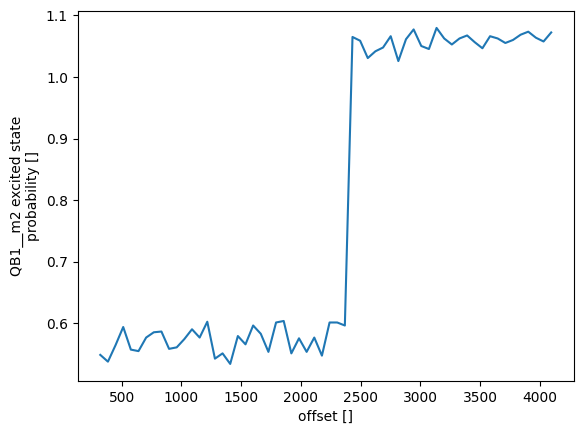

In [14]:
job = pulla.submit_playlist(job_definition, context=context)
job.wait_for_completion()
result = job.result(compiler)

# Plot the QB1 excited state probability in the second measurement
result.dataset["QB1__m2_excited_state_probability"].plot()